Accuracy : 0.968609865470852
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.93      1115
weighted avg       0.97      0.97      0.97      1115



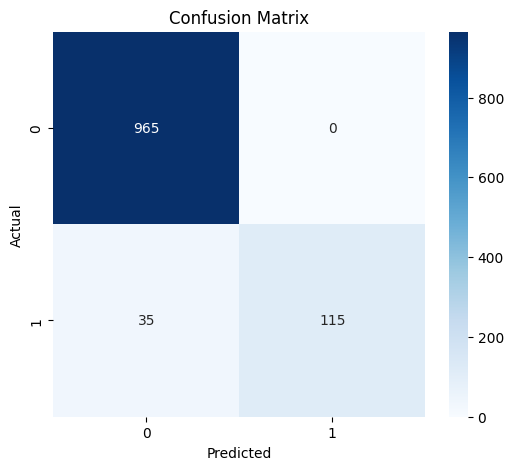

Model Saved Successfully
Spam Message


In [1]:
# ============================
# Spam SMS Detection
# ============================

# Install Libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Dataset
df = pd.read_csv("spam.csv", encoding="latin1")

# Remove unnecessary columns
df = df[['v1', 'v2']]

# Rename columns
df.columns = ['label', 'message']

# Convert labels
df['label'] = df['label'].map({'ham':0, 'spam':1})

# Features and Labels
X = df['message']
y = df['label']

# Convert text to vectors
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(X)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
model = MultinomialNB()

model.fit(X_train, y_train)

# Prediction
prediction = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, prediction)

print("Accuracy :", accuracy)

# Classification Report
print(classification_report(y_test, prediction))

# Confusion Matrix
cm = confusion_matrix(y_test, prediction)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Save Model
pickle.dump(model, open("spam_sms_model.pkl", "wb"))

print("Model Saved Successfully")

# Test Prediction
sample = ["Congratulations! You have won a free iPhone. Click here to claim now!"]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Ham Message")